# DATA 266 Lab 1 - Task 3: CycleGAN Monet <-> Photo (Sadaf Fatima Syeda)




In [ ]:
# Hyperparameters and settings
SMOKE = False

CFG = dict(
    member         = "Sadaf_Fatima_Syeda",
    seed           = 266,
    run_tag        = "full",
    img_size       = 256,
    load_size      = 286,             #
    n_holdout      = 300,             # first 300 photos (sorted) never used in training
    n_audit        = 30,              # fixed human audit samples, taken from the holdout
    # generator: U-Net
    ngf            = 48,
    num_downs      = 8,
    max_mult       = 8,
    # discriminator: smaller PatchGAN
    ndf            = 64,
    d_layers       = 2,
    # losses
    gan_loss       = "bce",
    lambda_cycle   = 8.0,
    lambda_identity= 0.0,
    # optimisation
    lr             = 2e-4,
    betas          = (0.5, 0.999),
    batch_size     = 1,
    total_steps    = 20000,           # linear lr decay over the second half
    time_budget_min= 120,             # total_steps is cut down to fit this after a quick benchmark
    pool_size      = 50,
    amp            = True,
    log_every      = 50,
    sample_every   = 1000,
    ckpt_every     = 1000,
    # evaluation
    n_eval         = 300,
    gen_all_photos = True,
)
if SMOKE:
    CFG.update(img_size=64, load_size=72, ngf=16, num_downs=6, ndf=16, total_steps=40,
               time_budget_min=5, log_every=10, sample_every=20, ckpt_every=20,
               n_eval=40, n_holdout=40, n_audit=10, gen_all_photos=False, amp=False, run_tag="smoke")
print(CFG)

{'member': 'Sadaf_Fatima_Syeda', 'seed': 266, 'run_tag': 'full', 'img_size': 256, 'load_size': 286, 'n_holdout': 300, 'n_audit': 30, 'ngf': 48, 'num_downs': 8, 'max_mult': 8, 'ndf': 64, 'd_layers': 2, 'gan_loss': 'bce', 'lambda_cycle': 8.0, 'lambda_identity': 0.0, 'lr': 0.0002, 'betas': (0.5, 0.999), 'batch_size': 1, 'total_steps': 20000, 'time_budget_min': 120, 'pool_size': 50, 'amp': True, 'log_every': 50, 'sample_every': 1000, 'ckpt_every': 1000, 'n_eval': 300, 'gen_all_photos': True}


In [ ]:
# 1. Setup folders, seed, log file and hardware info
import os, sys, json, time, math, random, platform, subprocess, datetime, glob, shutil
import numpy as np, torch

OUT  = f"task3_gan/{CFG['member']}"
DATA = "task3_gan/data"
DIRS = {k: f"{OUT}/{k}" for k in ["src", "checkpoints", "outputs", "data_processed"]}
PRED_A2B, PRED_B2A = f"{OUT}/outputs/pred_A2B", f"{OUT}/outputs/pred_B2A"
LOGD, MAND = "reproducibility/raw_logs", "reproducibility/manifests"
for d in list(DIRS.values()) + [LOGD, MAND, DATA, PRED_A2B, PRED_B2A, f"{OUT}/outputs/samples"]:
    os.makedirs(d, exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(CFG["seed"])
device = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_NAME = torch.cuda.get_device_name(0) if device == "cuda" else (platform.processor() or platform.machine())

RUN_ID   = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_PATH = f"{LOGD}/task3_sadaf_{RUN_ID}.log"
_logf = open(LOG_PATH, "a", buffering=1)
def log(msg=""):
    line = f"[{datetime.datetime.now().isoformat(timespec='seconds')}] {msg}"
    print(line); _logf.write(line + "\n")
def sh(cmd):
    try: return subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip()
    except Exception as e: return f"n/a ({e})"

# Mount Drive so checkpoints survive a disconnect
DRIVE = None
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE = f"/content/drive/MyDrive/DATA266_Lab1_Checkpoints/Task3_Sadaf/{CFG['run_tag']}"
    os.makedirs(DRIVE, exist_ok=True)
except Exception:
    pass

log(f"RUN_ID {RUN_ID} | python {sys.version.split()[0]} | torch {torch.__version__} | device {device} ({DEVICE_NAME})")
log("nvidia-smi:\n" + (sh("nvidia-smi") or "n/a"))
log("CPU: " + (sh("lscpu | grep 'Model name'") or platform.processor()) + f" | {os.cpu_count()} cores")
log(f"Drive checkpoint folder: {DRIVE}")
log("CONFIG " + json.dumps(CFG))
json.dump(CFG, open(f"{DIRS['outputs']}/config.json", "w"), indent=2)

Mounted at /content/drive
[2026-09-27T18:19:06] RUN_ID 20260927_181844 | python 3.13.15 | torch 2.11.0+cu128 | device cuda (Tesla T4)
[2026-09-27T18:19:06] nvidia-smi:
Sun Sep 27 18:19:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             12W /   70W |       3MiB /  15360M

In [ ]:
# 2. Download the competition data (monet_jpg + photo_jpg) and make the holdout split
import zipfile
if not (os.path.isdir(f"{DATA}/monet_jpg") and os.path.isdir(f"{DATA}/photo_jpg")):
    zip_path = "gan_dataset.zip"
    if not os.path.exists(zip_path):
        import gdown
        gdown.download("https://drive.google.com/uc?id=134CWIvesmfKNRHsX_CWI_jpdgHYeWcZc", zip_path, quiet=False)
    with zipfile.ZipFile(zip_path) as z:
        for n in z.namelist():
            if n.startswith("__MACOSX") or n.endswith("/") or n.endswith(".DS_Store"):
                continue
            parts = n.split("/")
            if len(parts) >= 2 and parts[-2] in ("monet_jpg", "photo_jpg"):
                os.makedirs(f"{DATA}/{parts[-2]}", exist_ok=True)
                with open(f"{DATA}/{parts[-2]}/{parts[-1]}", "wb") as f:
                    f.write(z.read(n))

def list_images(folder):
    exts = (".jpg", ".jpeg", ".png")
    paths = [p for p in glob.glob(os.path.join(folder, "*")) if p.lower().endswith(exts)]
    return sorted(set(paths))

monet_paths = list_images(f"{DATA}/monet_jpg")
photo_paths = list_images(f"{DATA}/photo_jpg")
if SMOKE:
    photo_paths = photo_paths[:300]


holdout_photos = photo_paths[:CFG["n_holdout"]]
train_photos   = photo_paths[CFG["n_holdout"]:]
rng = np.random.default_rng(CFG["seed"])
audit_photos = sorted(rng.choice(holdout_photos, CFG["n_audit"], replace=False).tolist())

from PIL import Image
sizes = {Image.open(p).size for p in monet_paths[:50] + photo_paths[:50]}
split = {"monet_all": [os.path.basename(p) for p in monet_paths],
         "photo_train": [os.path.basename(p) for p in train_photos],
         "photo_holdout": [os.path.basename(p) for p in holdout_photos],
         "audit_30": [os.path.basename(p) for p in audit_photos]}
json.dump(split, open(f"{DIRS['data_processed']}/holdout.json", "w"), indent=1)
log(f"Monet {len(monet_paths)} | photos {len(photo_paths)} -> train {len(train_photos)}, holdout {len(holdout_photos)} | "
    f"audit {len(audit_photos)} | image sizes {sizes}")

Downloading...
From (original): https://drive.google.com/uc?id=134CWIvesmfKNRHsX_CWI_jpdgHYeWcZc
From (redirected): https://drive.google.com/uc?id=134CWIvesmfKNRHsX_CWI_jpdgHYeWcZc&confirm=t&uuid=3990ce35-38f7-4874-bb5e-37b58ff8a28d
To: /content/gan_dataset.zip
100%|██████████| 106M/106M [00:01<00:00, 56.8MB/s]


[2026-09-27T18:20:00] Monet 300 | photos 7038 -> train 6738, holdout 300 | audit 30 | image sizes {(256, 256)}


In [ ]:
# 3. Unpaired dataset with random jitter (resize 286 -> random crop 256 -> random flip)
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

S, LS = CFG["img_size"], CFG["load_size"]
train_tf = T.Compose([T.Resize(LS, interpolation=T.InterpolationMode.BICUBIC), T.RandomCrop(S),
                      T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize([0.5] * 3, [0.5] * 3)])
test_tf  = T.Compose([T.Resize(S, interpolation=T.InterpolationMode.BICUBIC), T.ToTensor(), T.Normalize([0.5] * 3, [0.5] * 3)])

class Unpaired(Dataset):
    """ Each item is one random Monet (A) and one random photo (B), no pairing """
    def __init__(self, a_paths, b_paths, length):
        self.a = [Image.open(p).convert("RGB") for p in a_paths]   # 300 Monets fit in memory
        self.b_paths, self.length = b_paths, length
    def __len__(self): return self.length
    def __getitem__(self, i):
        a = self.a[random.randrange(len(self.a))]
        b = Image.open(self.b_paths[random.randrange(len(self.b_paths))]).convert("RGB")
        return train_tf(a), train_tf(b)

def load_test(paths):
    return torch.stack([test_tf(Image.open(p).convert("RGB")) for p in paths])

log(f"train transform: resize {LS} -> crop {S} -> flip | test: resize {S}")

[2026-09-27T18:23:06] train transform: resize 286 -> crop 256 -> flip | test: resize 256


In [ ]:
# 4. Models: U-Net generator and smaller PatchGAN discriminator
import torch.nn as nn
from torch.nn import functional as F

class UNetGenerator(nn.Module):
    """ U-Net with skip connections, 256 -> 1x1 bottleneck when num_downs = 8 """
    def __init__(self, ngf=48, num_downs=8, max_mult=8):
        super().__init__()
        ch = [min(ngf * 2 ** i, ngf * max_mult) for i in range(num_downs)]
        self.downs = nn.ModuleList()
        for i in range(num_downs):
            layers = [] if i == 0 else [nn.LeakyReLU(0.2, True)]
            layers.append(nn.Conv2d(3 if i == 0 else ch[i - 1], ch[i], 4, 2, 1, bias=False))
            if 0 < i < num_downs - 1:
                layers.append(nn.InstanceNorm2d(ch[i]))
            self.downs.append(nn.Sequential(*layers))
        self.ups = nn.ModuleList()
        for i in reversed(range(num_downs)):
            in_ch = ch[i] if i == num_downs - 1 else ch[i] * 2
            if i == 0:
                self.ups.append(nn.Sequential(nn.ReLU(True), nn.ConvTranspose2d(in_ch, 3, 4, 2, 1), nn.Tanh()))
            else:
                self.ups.append(nn.Sequential(nn.ReLU(True), nn.ConvTranspose2d(in_ch, ch[i - 1], 4, 2, 1, bias=False),
                                              nn.InstanceNorm2d(ch[i - 1])))
    def forward(self, x):
        skips = []
        for d in self.downs:
            x = d(x); skips.append(x)
        x = self.ups[0](skips[-1])
        for up, skip in zip(self.ups[1:], reversed(skips[:-1])):
            x = up(torch.cat([x, skip], 1))
        return x

class PatchDiscriminator(nn.Module):
    """ PatchGAN with fewer layers (smaller receptive field), outputs logits per patch """
    def __init__(self, ndf=64, n_layers=2):
        super().__init__()
        layers = [nn.Conv2d(3, ndf, 4, 2, 1), nn.LeakyReLU(0.2, True)]
        mult = 1
        for n in range(1, n_layers + 1):
            prev, mult = mult, min(2 ** n, 8)
            stride = 2 if n < n_layers else 1
            layers += [nn.Conv2d(ndf * prev, ndf * mult, 4, stride, 1, bias=False), nn.InstanceNorm2d(ndf * mult),
                       nn.LeakyReLU(0.2, True)]
        layers.append(nn.Conv2d(ndf * mult, 1, 4, 1, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None: nn.init.zeros_(m.bias)

G_AB = UNetGenerator(CFG["ngf"], CFG["num_downs"], CFG["max_mult"]).to(device)   # Monet -> Photo
G_BA = UNetGenerator(CFG["ngf"], CFG["num_downs"], CFG["max_mult"]).to(device)   # Photo -> Monet
D_A  = PatchDiscriminator(CFG["ndf"], CFG["d_layers"]).to(device)                # real vs fake Monet
D_B  = PatchDiscriminator(CFG["ndf"], CFG["d_layers"]).to(device)                # real vs fake Photo
for m in (G_AB, G_BA, D_A, D_B): m.apply(init_weights)

count = lambda m: sum(p.numel() for p in m.parameters())
PARAMS = {"G_AB": count(G_AB), "G_BA": count(G_BA), "D_A": count(D_A), "D_B": count(D_B)}
PARAMS["total"] = sum(PARAMS.values())
with torch.no_grad():
    d_out = D_A(torch.zeros(1, 3, S, S, device=device)).shape
log(f"params {json.dumps(PARAMS)} | D output map {tuple(d_out)}")

[2026-09-27T18:24:47] params {"G_AB": 30604035, "G_BA": 30604035, "D_A": 662593, "D_B": 662593, "total": 62533256} | D output map (1, 1, 62, 62)


In [ ]:
# 5. Training loop: adversarial (BCE) + cycle-consistency loss, image pool, linear lr decay,
# gradient norms, NaN count, sample grids, checkpoints (resumes from Drive after a disconnect)
import itertools
from torchvision.utils import save_image

class ImagePool:
    """ Keeps 50 old fakes so D also sees earlier generator outputs """
    def __init__(self, size): self.size, self.imgs = size, []
    def query(self, x):
        if self.size == 0: return x
        out = []
        for img in x:
            img = img.unsqueeze(0)
            if len(self.imgs) < self.size:
                self.imgs.append(img); out.append(img)
            elif random.random() > 0.5:
                j = random.randrange(self.size); out.append(self.imgs[j].clone()); self.imgs[j] = img
            else:
                out.append(img)
        return torch.cat(out, 0)

bce = nn.BCEWithLogitsLoss()
def gan_loss(logits, is_real):
    return bce(logits, torch.ones_like(logits) if is_real else torch.zeros_like(logits))
l1 = nn.L1Loss()

opt_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=CFG["lr"], betas=CFG["betas"])
opt_D = torch.optim.Adam(itertools.chain(D_A.parameters(), D_B.parameters()), lr=CFG["lr"], betas=CFG["betas"])
PLAN = {"total_steps": CFG["total_steps"]}
def lr_factor(step):
    half = PLAN["total_steps"] // 2
    return 1.0 if step < half else max(0.0, 1.0 - (step - half) / max(1, PLAN["total_steps"] - half))
sch_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_factor)
sch_D = torch.optim.lr_scheduler.LambdaLR(opt_D, lr_factor)
use_amp = CFG["amp"] and device == "cuda"
scaler_G = torch.amp.GradScaler("cuda", enabled=use_amp)
scaler_D = torch.amp.GradScaler("cuda", enabled=use_amp)
autocast = lambda: torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp)
pool_A, pool_B = ImagePool(CFG["pool_size"]), ImagePool(CFG["pool_size"])

H = {k: [] for k in ["step", "G_total", "G_gan_AB", "G_gan_BA", "cycle", "identity", "D_A", "D_B",
                     "D_A_real", "D_A_fake", "D_B_real", "D_B_fake", "gnorm_G", "gnorm_D", "lr"]}
state = {"step": 0, "nan_steps": 0, "train_time": 0.0}
CKPT = f"{DIRS['checkpoints']}/last.pt"

def save_ckpt(path):
    torch.save({"G_AB": G_AB.state_dict(), "G_BA": G_BA.state_dict(), "D_A": D_A.state_dict(), "D_B": D_B.state_dict(),
                "opt_G": opt_G.state_dict(), "opt_D": opt_D.state_dict(), "sch_G": sch_G.state_dict(),
                "sch_D": sch_D.state_dict(), "H": H, "state": state, "plan": PLAN, "cfg": CFG}, path)

resume = f"{DRIVE}/last.pt" if DRIVE and os.path.exists(f"{DRIVE}/last.pt") else (CKPT if os.path.exists(CKPT) else None)
if resume:
    ck = torch.load(resume, map_location=device, weights_only=False)
    for k, m in [("G_AB", G_AB), ("G_BA", G_BA), ("D_A", D_A), ("D_B", D_B), ("opt_G", opt_G), ("opt_D", opt_D),
                 ("sch_G", sch_G), ("sch_D", sch_D)]:
        m.load_state_dict(ck[k])
    H, state, PLAN = ck["H"], ck["state"], ck["plan"]
    log(f"RESUMED from {resume} at step {state['step']} / {PLAN['total_steps']}")

fixed_A = load_test(monet_paths[:4]).to(device)
fixed_B = load_test(holdout_photos[:4]).to(device)
def save_samples(step):
    G_AB.eval(); G_BA.eval()
    with torch.no_grad():
        fb = G_AB(fixed_A); ra = G_BA(fb); fa = G_BA(fixed_B); rb = G_AB(fa)
    grid = torch.cat([fixed_A, fb, ra, fixed_B, fa, rb], 0) * 0.5 + 0.5
    save_image(grid, f"{OUT}/outputs/samples/step_{step:06d}.png", nrow=4)
    G_AB.train(); G_BA.train()

loader = DataLoader(Unpaired(monet_paths, train_photos, 10 ** 9), batch_size=CFG["batch_size"],
                    num_workers=2 if device == "cuda" else 0, pin_memory=device == "cuda")
it = iter(loader)
if device == "cuda": torch.cuda.reset_peak_memory_stats()
G_AB.train(); G_BA.train(); D_A.train(); D_B.train()
acc = {k: [] for k in H if k not in ("step", "lr")}
t_start, t_last = time.time(), time.time()
log(f"training from step {state['step']} to {PLAN['total_steps']} | amp {use_amp}")

while state["step"] < PLAN["total_steps"]:
    real_A, real_B = [x.to(device, non_blocking=True) for x in next(it)]
    step = state["step"]

    # Generator step (D frozen)
    for p in itertools.chain(D_A.parameters(), D_B.parameters()): p.requires_grad_(False)
    with autocast():
        fake_B = G_AB(real_A); rec_A = G_BA(fake_B)
        fake_A = G_BA(real_B); rec_B = G_AB(fake_A)
        g_ab = gan_loss(D_B(fake_B), True)
        g_ba = gan_loss(D_A(fake_A), True)
        cyc = l1(rec_A, real_A) + l1(rec_B, real_B)
        if CFG["lambda_identity"] > 0:
            idt = l1(G_BA(real_A), real_A) + l1(G_AB(real_B), real_B)
        loss_G = g_ab + g_ba + CFG["lambda_cycle"] * cyc + (CFG["lambda_identity"] * idt if CFG["lambda_identity"] > 0 else 0)
    if not torch.isfinite(loss_G):
        state["nan_steps"] += 1; log(f"step {step}: non-finite G loss, skipped")
        opt_G.zero_grad(set_to_none=True); state["step"] += 1; sch_G.step(); sch_D.step(); continue
    opt_G.zero_grad(set_to_none=True)
    scaler_G.scale(loss_G).backward()
    scaler_G.unscale_(opt_G)
    gn_G = torch.nn.utils.clip_grad_norm_(itertools.chain(G_AB.parameters(), G_BA.parameters()), 1e9).item()
    scaler_G.step(opt_G); scaler_G.update()

    # Discriminator step (with image pool)
    for p in itertools.chain(D_A.parameters(), D_B.parameters()): p.requires_grad_(True)
    with autocast():
        pa, pb = pool_A.query(fake_A.detach()), pool_B.query(fake_B.detach())
        dar, daf = D_A(real_A), D_A(pa)
        dbr, dbf = D_B(real_B), D_B(pb)
        loss_DA = 0.5 * (gan_loss(dar, True) + gan_loss(daf, False))
        loss_DB = 0.5 * (gan_loss(dbr, True) + gan_loss(dbf, False))
        loss_D = loss_DA + loss_DB
    if not torch.isfinite(loss_D):
        state["nan_steps"] += 1; log(f"step {step}: non-finite D loss, skipped")
        opt_D.zero_grad(set_to_none=True); state["step"] += 1; sch_G.step(); sch_D.step(); continue
    opt_D.zero_grad(set_to_none=True)
    scaler_D.scale(loss_D).backward()
    scaler_D.unscale_(opt_D)
    gn_D = torch.nn.utils.clip_grad_norm_(itertools.chain(D_A.parameters(), D_B.parameters()), 1e9).item()
    scaler_D.step(opt_D); scaler_D.update()
    sch_G.step(); sch_D.step()
    state["step"] += 1

    # Running averages, flushed every log_every steps
    with torch.no_grad():
        if CFG["lambda_identity"] == 0 and state["step"] % CFG["log_every"] == 0:
            with autocast():
                idt = l1(G_BA(real_A), real_A) + l1(G_AB(real_B), real_B)   # logged only, not trained
        for k, v in [("G_total", loss_G), ("G_gan_AB", g_ab), ("G_gan_BA", g_ba), ("cycle", cyc), ("D_A", loss_DA),
                     ("D_B", loss_DB), ("D_A_real", torch.sigmoid(dar).mean()), ("D_A_fake", torch.sigmoid(daf).mean()),
                     ("D_B_real", torch.sigmoid(dbr).mean()), ("D_B_fake", torch.sigmoid(dbf).mean())]:
            acc[k].append(float(v))
        acc["gnorm_G"].append(gn_G); acc["gnorm_D"].append(gn_D)
    if state["step"] % CFG["log_every"] == 0:
        H["step"].append(state["step"]); H["lr"].append(sch_G.get_last_lr()[0]); H["identity"].append(float(idt))
        for k in acc:
            if k != "identity": H[k].append(float(np.mean(acc[k])) if acc[k] else float("nan"))
        acc = {k: [] for k in acc}
        now = time.time(); state["train_time"] += now - t_last; t_last = now
        log(f"step {state['step']}/{PLAN['total_steps']} | G {H['G_total'][-1]:.3f} (gan {H['G_gan_AB'][-1]:.3f}/"
            f"{H['G_gan_BA'][-1]:.3f}, cyc {H['cycle'][-1]:.3f}, idt {H['identity'][-1]:.3f}) | D_A {H['D_A'][-1]:.3f} "
            f"D_B {H['D_B'][-1]:.3f} | gnorm G {H['gnorm_G'][-1]:.2f} D {H['gnorm_D'][-1]:.2f} | lr {H['lr'][-1]:.2e}")

    # Fit total_steps to the time budget after a short benchmark (only on a fresh run)
    bench = 20 if SMOKE else 200
    if state["step"] == bench and not resume:
        sps = (time.time() - t_start) / bench
        fit = int(CFG["time_budget_min"] * 60 / sps * 0.95)
        if fit < PLAN["total_steps"]:
            PLAN["total_steps"] = max(fit, bench * 2)
        log(f"benchmark {sps:.3f} s/step ({1/sps:.1f} steps/s) -> total_steps {PLAN['total_steps']} "
            f"(~{PLAN['total_steps'] * sps / 60:.0f} min)")

    if state["step"] % CFG["sample_every"] == 0:
        save_samples(state["step"])
    if state["step"] % CFG["ckpt_every"] == 0:
        save_ckpt(CKPT)
        if DRIVE: shutil.copy(CKPT, f"{DRIVE}/last.pt")

state["train_time"] += time.time() - t_last
save_samples(state["step"]); save_ckpt(CKPT)
if DRIVE: shutil.copy(CKPT, f"{DRIVE}/last.pt")
PEAK_TRAIN_MB = torch.cuda.max_memory_allocated() / 1024 ** 2 if device == "cuda" else float("nan")
TRAIN_IPS = state["step"] * CFG["batch_size"] * 2 / max(state["train_time"], 1e-9)   # one Monet + one photo per step
log(f"DONE {state['step']} steps | train time {state['train_time']/60:.1f} min | {TRAIN_IPS:.1f} images/s | "
    f"peak memory {PEAK_TRAIN_MB:.0f} MB | non-finite steps {state['nan_steps']}")

[2026-09-27T18:25:50] training from step 0 to 20000 | amp True


/tmp/ipykernel_1416/2054729000.py:120: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sch_G.step(); sch_D.step()


[2026-09-27T18:25:55] step 50/20000 | G 6.819 (gan 0.769/0.769, cyc 0.660, idt 1.219) | D_A 0.698 D_B 0.695 | gnorm G inf D 3.70 | lr 2.00e-04
[2026-09-27T18:25:59] step 100/20000 | G 5.523 (gan 0.716/0.741, cyc 0.508, idt 1.187) | D_A 0.663 D_B 0.659 | gnorm G 12.68 D 3.62 | lr 2.00e-04
[2026-09-27T18:26:03] step 150/20000 | G 5.363 (gan 0.711/0.709, cyc 0.493, idt 1.511) | D_A 0.667 D_B 0.667 | gnorm G 14.77 D 3.33 | lr 2.00e-04
[2026-09-27T18:26:07] step 200/20000 | G 5.288 (gan 0.740/0.732, cyc 0.477, idt 1.256) | D_A 0.655 D_B 0.660 | gnorm G 16.21 D 3.90 | lr 2.00e-04
[2026-09-27T18:26:07] benchmark 0.084 s/step (11.9 steps/s) -> total_steps 20000 (~28 min)
[2026-09-27T18:26:11] step 250/20000 | G 4.962 (gan 0.730/0.724, cyc 0.439, idt 1.436) | D_A 0.668 D_B 0.663 | gnorm G 14.36 D 3.58 | lr 2.00e-04
[2026-09-27T18:26:15] step 300/20000 | G 4.711 (gan 0.748/0.721, cyc 0.405, idt 1.124) | D_A 0.680 D_B 0.658 | gnorm G 12.75 D 3.76 | lr 2.00e-04
[2026-09-27T18:26:19] step 350/20000

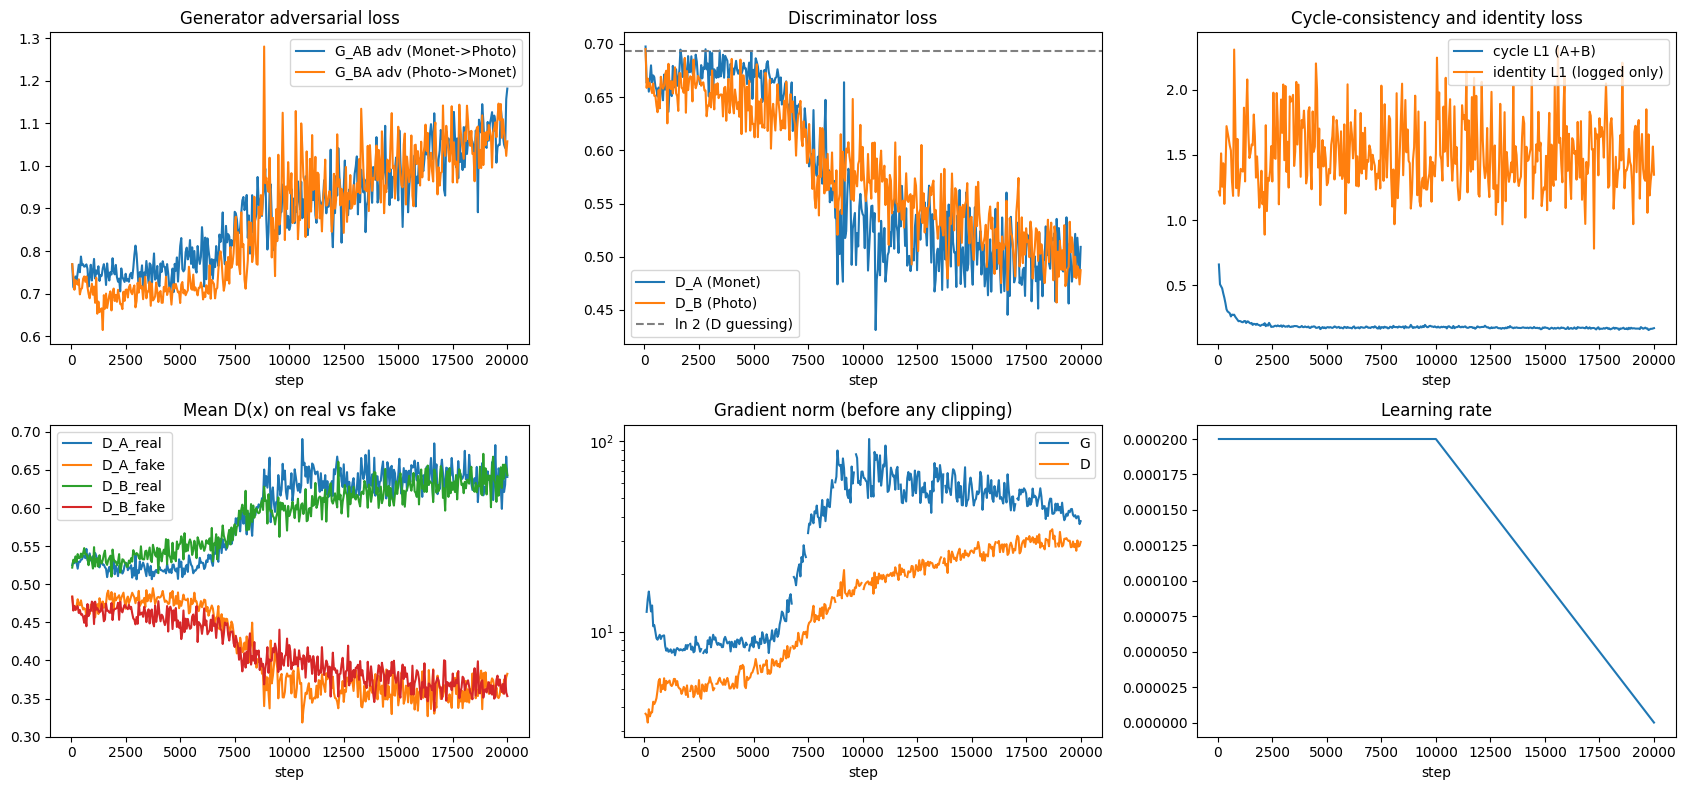

[2026-09-27T18:58:49] STABILITY {"D_A_loss_last20pct": 0.4992, "D_B_loss_last20pct": 0.5065, "G_adv_std_last20pct": 0.0512, "cycle_first_log": 0.66, "cycle_last20pct": 0.1707, "gnorm_G_max": Infinity, "gnorm_D_max": Infinity}


In [ ]:
# 6. Loss curves and training stability plots
import matplotlib.pyplot as plt, pandas as pd
hist = pd.DataFrame(H)
hist.to_csv(f"{OUT}/outputs/training_history.csv", index=False)

fig, ax = plt.subplots(2, 3, figsize=(17, 8))
ax[0, 0].plot(hist.step, hist.G_gan_AB, label="G_AB adv (Monet->Photo)"); ax[0, 0].plot(hist.step, hist.G_gan_BA, label="G_BA adv (Photo->Monet)")
ax[0, 0].set_title("Generator adversarial loss"); ax[0, 0].legend()
ax[0, 1].plot(hist.step, hist.D_A, label="D_A (Monet)"); ax[0, 1].plot(hist.step, hist.D_B, label="D_B (Photo)")
ax[0, 1].axhline(math.log(2), ls="--", c="gray", label="ln 2 (D guessing)"); ax[0, 1].set_title("Discriminator loss"); ax[0, 1].legend()
ax[0, 2].plot(hist.step, hist.cycle, label="cycle L1 (A+B)"); ax[0, 2].plot(hist.step, hist.identity, label="identity L1 (logged only)")
ax[0, 2].set_title("Cycle-consistency and identity loss"); ax[0, 2].legend()
for k in ["D_A_real", "D_A_fake", "D_B_real", "D_B_fake"]: ax[1, 0].plot(hist.step, hist[k], label=k)
ax[1, 0].set_title("Mean D(x) on real vs fake"); ax[1, 0].legend()
ax[1, 1].plot(hist.step, hist.gnorm_G, label="G"); ax[1, 1].plot(hist.step, hist.gnorm_D, label="D")
ax[1, 1].set_yscale("log"); ax[1, 1].set_title("Gradient norm (before any clipping)"); ax[1, 1].legend()
ax[1, 2].plot(hist.step, hist.lr); ax[1, 2].set_title("Learning rate")
for a in ax.flat: a.set_xlabel("step")
plt.tight_layout(); plt.savefig(f"{OUT}/outputs/loss_curves.png", dpi=150, bbox_inches="tight"); plt.show()

# Simple stability numbers over the last 20% of training
tail = hist[hist.step >= hist.step.max() * 0.8]
STAB = {"D_A_loss_last20pct": tail.D_A.mean(), "D_B_loss_last20pct": tail.D_B.mean(),
        "G_adv_std_last20pct": float(pd.concat([tail.G_gan_AB, tail.G_gan_BA]).std()),
        "cycle_first_log": hist.cycle.iloc[0], "cycle_last20pct": tail.cycle.mean(),
        "gnorm_G_max": hist.gnorm_G.max(), "gnorm_D_max": hist.gnorm_D.max()}
log("STABILITY " + json.dumps({k: round(float(v), 4) for k, v in STAB.items()}))

[2026-09-27T18:59:59] pred_A2B 300 images (65.8 img/s) | pred_B2A 7038 images (118.4 img/s) | peak inference memory 1283 MB


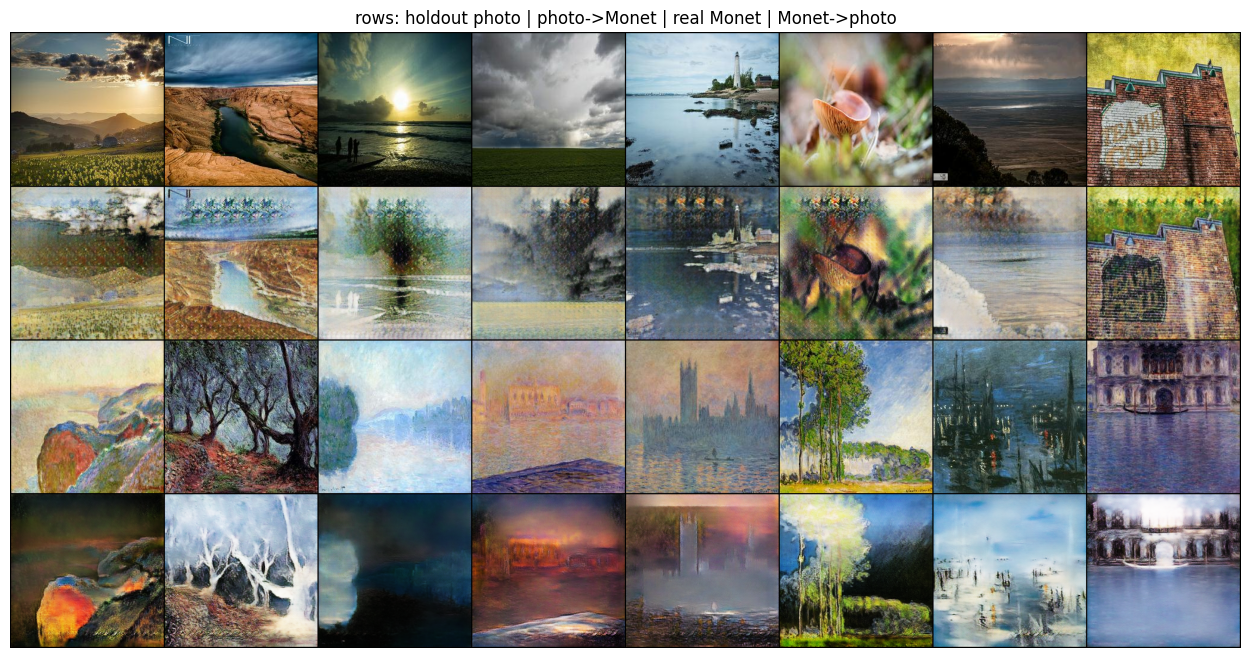

In [ ]:
# 7. Translate: all Monets -> pred_A2B, photos -> pred_B2A (256x256 RGB JPG, named after the input)
G_AB.eval(); G_BA.eval()
def translate(G, paths, out_dir, bs=16):
    n, t0 = 0, time.time()
    if device == "cuda": torch.cuda.synchronize()
    with torch.no_grad():
        for i in range(0, len(paths), bs):
            batch = paths[i:i + bs]
            y = G(load_test(batch).to(device)).clamp(-1, 1) * 0.5 + 0.5
            y = (y * 255).round().byte().permute(0, 2, 3, 1).cpu().numpy()
            for p, arr in zip(batch, y):
                name = os.path.splitext(os.path.basename(p))[0] + ".jpg"
                Image.fromarray(arr).resize((256, 256), Image.BICUBIC).save(f"{out_dir}/{name}", quality=95)
                n += 1
    if device == "cuda": torch.cuda.synchronize()
    return n / (time.time() - t0)

for d in (PRED_A2B, PRED_B2A):
    for f in glob.glob(f"{d}/*"): os.remove(f)
if device == "cuda": torch.cuda.reset_peak_memory_stats()
ips_A2B = translate(G_AB, monet_paths, PRED_A2B)
ips_B2A = translate(G_BA, photo_paths if CFG["gen_all_photos"] else holdout_photos, PRED_B2A)
PEAK_INFER_MB = torch.cuda.max_memory_allocated() / 1024 ** 2 if device == "cuda" else float("nan")
log(f"pred_A2B {len(os.listdir(PRED_A2B))} images ({ips_A2B:.1f} img/s) | pred_B2A {len(os.listdir(PRED_B2A))} images "
    f"({ips_B2A:.1f} img/s) | peak inference memory {PEAK_INFER_MB:.0f} MB")

# Final visual grid: holdout photos -> Monet style, and Monets -> photo style
grid_B = load_test(holdout_photos[:8]).to(device); grid_A = load_test(monet_paths[:8]).to(device)
with torch.no_grad():
    save_image(torch.cat([grid_B, G_BA(grid_B), grid_A, G_AB(grid_A)]) * 0.5 + 0.5, f"{OUT}/outputs/final_grid.png", nrow=8)
plt.figure(figsize=(16, 8)); plt.imshow(Image.open(f"{OUT}/outputs/final_grid.png")); plt.axis("off")
plt.title("rows: holdout photo | photo->Monet | real Monet | Monet->photo"); plt.show()

In [ ]:
%%writefile task3_gan/Sadaf_Fatima_Syeda/evaluate_local.py

# plus KID and generative precision / recall / density / coverage on the same Inception features.
# Usage: python evaluate_local.py --data task3_gan/data --pred task3_gan/Sadaf_Fatima_Syeda/outputs
import os, glob, json, argparse
import numpy as np, pandas as pd, torch, torch.nn as nn
import torchvision.transforms as T, torchvision.models as models
import scipy.linalg
from scipy.spatial.distance import cosine
from PIL import Image

INCEPTION_TF = T.Compose([T.Resize(299), T.CenterCrop(299), T.ToTensor(),
                          T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])

def list_images(folder):
    exts = (".jpg", ".jpeg", ".png")
    paths = []
    for ext in exts:
        paths.extend(glob.glob(os.path.join(folder, f"*{ext}")))
        paths.extend(glob.glob(os.path.join(folder, f"*{ext.upper()}")))
    return sorted(list(set(paths)))

def take_n(paths, n):
    return paths if n is None else paths[:min(n, len(paths))]

def get_inception_model(device, random_weights=False):
    weights = None if random_weights else models.Inception_V3_Weights.IMAGENET1K_V1
    m = models.inception_v3(weights=weights, transform_input=False, aux_logits=True, init_weights=random_weights)
    m.fc = nn.Identity()
    return m.to(device).eval()

@torch.no_grad()
def get_activations(model, paths, device, batch_size=32):
    feats = []
    for i in range(0, len(paths), batch_size):
        x = torch.stack([INCEPTION_TF(Image.open(p).convert("RGB")) for p in paths[i:i + batch_size]]).to(device)
        feats.append(model(x).detach().cpu().numpy())
    return np.concatenate(feats, axis=0)

def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    covmean, _ = scipy.linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    diff = mu1 - mu2
    return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))

def fid_mifid(real_act, gen_act):
    """ Same as the official calculate_fid_mifid, on precomputed features (inputs already sorted and matched) """
    mu_r, sig_r = real_act.mean(axis=0), np.cov(real_act, rowvar=False)
    mu_g, sig_g = gen_act.mean(axis=0), np.cov(gen_act, rowvar=False)
    fid = frechet_distance(mu_r, sig_r, mu_g, sig_g)
    m = min(len(real_act), len(gen_act))
    mifid = float(np.mean([cosine(real_act[i], gen_act[i]) for i in range(m)]))
    return fid, mifid

def kid(real, gen, n_subsets=50, subset_size=100, seed=0):
    """ Kernel Inception Distance: unbiased MMD^2 with a cubic polynomial kernel """
    rng = np.random.default_rng(seed); d = real.shape[1]; m = min(subset_size, len(real), len(gen)); vals = []
    for _ in range(n_subsets):
        x = real[rng.choice(len(real), m, replace=False)]; y = gen[rng.choice(len(gen), m, replace=False)]
        kxx = (x @ x.T / d + 1) ** 3; kyy = (y @ y.T / d + 1) ** 3; kxy = (x @ y.T / d + 1) ** 3
        vals.append((kxx.sum() - np.trace(kxx)) / (m * (m - 1)) + (kyy.sum() - np.trace(kyy)) / (m * (m - 1)) - 2 * kxy.mean())
    return float(np.mean(vals)), float(np.std(vals))

def prdc(real, gen, k=3):
    """ Precision / recall (Kynkaanniemi et al.) and density / coverage (Naeem et al.) """
    def dists(a, b):
        return np.sqrt(np.maximum((a ** 2).sum(1)[:, None] + (b ** 2).sum(1)[None] - 2 * a @ b.T, 0))
    rr, gg, rg = dists(real, real), dists(gen, gen), dists(real, gen)
    r_rad = np.sort(rr, 1)[:, k]; g_rad = np.sort(gg, 1)[:, k]
    precision = float((rg <= r_rad[:, None]).any(0).mean())
    recall = float((rg <= g_rad[None, :]).any(1).mean())
    density = float((rg <= r_rad[:, None]).sum(0).mean() / k)
    coverage = float((rg.min(1) <= r_rad).mean())
    return precision, recall, density, coverage

def evaluate(data_dir, pred_dir, n_eval=300, out_dir=".", random_weights=False, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    sets = {"real_monet": f"{data_dir}/monet_jpg", "real_photo": f"{data_dir}/photo_jpg",
            "gen_a2b": f"{pred_dir}/pred_A2B", "gen_b2a": f"{pred_dir}/pred_B2A"}
    paths = {k: take_n(list_images(v), n_eval) for k, v in sets.items()}
    model = get_inception_model(device, random_weights)
    res = {}
    for name, real_k, gen_k in [("B2A", "real_monet", "gen_b2a"), ("A2B", "real_photo", "gen_a2b")]:
        n = min(len(paths[real_k]), len(paths[gen_k]))
        real = get_activations(model, sorted(paths[real_k])[:n], device)
        gen = get_activations(model, sorted(paths[gen_k])[:n], device)
        res[f"FID_{name}"], res[f"MiFID_{name}"] = fid_mifid(real, gen)
        res[f"KID_{name}"], res[f"KID_std_{name}"] = kid(real, gen)
        res[f"precision_{name}"], res[f"recall_{name}"], res[f"density_{name}"], res[f"coverage_{name}"] = prdc(real, gen)
        res[f"n_{name}"] = n
    res["FID"] = (res["FID_A2B"] + res["FID_B2A"]) / 2
    res["MiFID"] = (res["MiFID_A2B"] + res["MiFID_B2A"]) / 2
    res["leaderboard_score_estimate"] = (res["FID"] + res["MiFID"]) / 2
    pd.DataFrame([{"ID": 1, "FID": float(res["FID"]), "MiFID": float(res["MiFID"])}]).to_csv(f"{out_dir}/submission.csv", index=False)
    json.dump(res, open(f"{out_dir}/evaluation.json", "w"), indent=2)
    return res

if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--data", default="task3_gan/data")
    ap.add_argument("--pred", default="task3_gan/Sadaf_Fatima_Syeda/outputs")
    ap.add_argument("--n_eval", type=int, default=300)
    ap.add_argument("--out", default="task3_gan/Sadaf_Fatima_Syeda")
    a, _ = ap.parse_known_args()
    print(json.dumps(evaluate(a.data, a.pred, a.n_eval, a.out), indent=2))

Writing task3_gan/Sadaf_Fatima_Syeda/evaluate_local.py


In [ ]:
# 8. Kaggle submission (FID / MiFID, official method) + KID + precision / recall / density / coverage
sys.path.insert(0, OUT)
import importlib, evaluate_local; importlib.reload(evaluate_local)
try:
    EVAL = evaluate_local.evaluate(DATA, f"{OUT}/outputs", CFG["n_eval"], OUT)
except Exception as e:
    if not SMOKE: raise
    log(f"SMOKE: pretrained Inception not downloadable here ({type(e).__name__}), using random weights (numbers meaningless)")
    EVAL = evaluate_local.evaluate(DATA, f"{OUT}/outputs", CFG["n_eval"], OUT, random_weights=True)
log("EVAL " + json.dumps({k: round(v, 5) if isinstance(v, float) else v for k, v in EVAL.items()}))
display(pd.read_csv(f"{OUT}/submission.csv"))

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 126MB/s] 


[2026-09-27T19:03:53] EVAL {"FID_B2A": 123.28288, "MiFID_B2A": 0.40464, "KID_B2A": 0.02879, "KID_std_B2A": 0.00352, "precision_B2A": 0.26667, "recall_B2A": 0.61333, "density_B2A": 0.16778, "coverage_B2A": 0.25667, "n_B2A": 300, "FID_A2B": 143.47715, "MiFID_A2B": 0.44304, "KID_A2B": 0.06137, "KID_std_A2B": 0.00568, "precision_A2B": 0.53333, "recall_A2B": 0.26333, "density_A2B": 0.51667, "coverage_A2B": 0.36333, "n_A2B": 300, "FID": 133.38002, "MiFID": 0.42384, "leaderboard_score_estimate": 66.90193}


,ID,FID,MiFID
0,1,133.380015,0.423837


In [ ]:
   !pip install -q lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.2 MB/s eta 0:00:00


In [ ]:
# 9. Cycle-reconstruction L1, identity L1, LPIPS and content-preservation cosine (input vs translation)
import lpips
try:
    lp = lpips.LPIPS(net="alex", verbose=False).to(device).eval()
except Exception as e:
    if not SMOKE: raise
    lp = lpips.LPIPS(net="alex", pnet_rand=True, verbose=False).to(device).eval()
try:
    inc = evaluate_local.get_inception_model(device)
except Exception:
    if not SMOKE: raise
    inc = evaluate_local.get_inception_model(device, random_weights=True)

eval_A = monet_paths[:CFG["n_eval"]]
eval_B = holdout_photos[:CFG["n_eval"]]
def model_metrics(G, G_back, paths, tag, bs=16):
    l1s, cyc_l1, idt_l1, lp_tr, lp_cyc, cos = [], [], [], [], [], []
    with torch.no_grad():
        for i in range(0, len(paths), bs):
            x = load_test(paths[i:i + bs]).to(device)
            y = G(x); r = G_back(y); idt = G_back(x)
            cyc_l1 += ((r - x).abs().mean((1, 2, 3)) / 2).tolist()      # on the 0-1 pixel scale
            idt_l1 += ((idt - x).abs().mean((1, 2, 3)) / 2).tolist()
            lp_tr += lp(x, y).flatten().tolist(); lp_cyc += lp(x, r).flatten().tolist()
            norm = lambda t: T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))(
                F.interpolate(t * 0.5 + 0.5, size=299, mode="bilinear", align_corners=False))
            fx, fy = inc(norm(x)), inc(norm(y))
            cos += F.cosine_similarity(fx, fy).tolist()
    return {f"cycle_L1_{tag}": np.mean(cyc_l1), f"identity_L1_{tag}": np.mean(idt_l1),
            f"LPIPS_input_vs_translation_{tag}": np.mean(lp_tr), f"LPIPS_input_vs_reconstruction_{tag}": np.mean(lp_cyc),
            f"content_cosine_{tag}": np.mean(cos)}

MM = {}
MM.update(model_metrics(G_AB, G_BA, eval_A, "A2B"))   # Monet -> Photo -> Monet
MM.update(model_metrics(G_BA, G_AB, eval_B, "B2A"))   # holdout Photo -> Monet -> Photo
log("MODEL METRICS " + json.dumps({k: round(float(v), 5) for k, v in MM.items()}))

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 83.5MB/s]


[2026-09-27T19:07:40] MODEL METRICS {"cycle_L1_A2B": 0.04651, "identity_L1_A2B": 0.33015, "LPIPS_input_vs_translation_A2B": 0.54108, "LPIPS_input_vs_reconstruction_A2B": 0.35003, "content_cosine_A2B": 0.6773, "cycle_L1_B2A": 0.04423, "identity_L1_B2A": 0.43282, "LPIPS_input_vs_translation_B2A": 0.56258, "LPIPS_input_vs_reconstruction_B2A": 0.31645, "content_cosine_B2A": 0.65524}


In [ ]:
# 10. Human audit: 30 fixed holdout photos, blinded order, 2 raters (style, content, artifacts on 1-5)
AUD = f"{OUT}/outputs/audit"
os.makedirs(f"{AUD}/images", exist_ok=True)
order = np.random.default_rng(CFG["seed"] + 1).permutation(len(audit_photos))
key = []
for n, j in enumerate(order, 1):
    p = audit_photos[j]
    x = load_test([p]).to(device)
    with torch.no_grad():
        y = G_BA(x)
    save_image(torch.cat([x, y]) * 0.5 + 0.5, f"{AUD}/images/sample_{n:02d}.png", nrow=2)   # input | translation
    key.append({"sample": f"sample_{n:02d}", "source_photo": os.path.basename(p)})
pd.DataFrame(key).to_csv(f"{AUD}/audit_key.csv", index=False)
for rater in ["rater1_Sadaf", "rater2_Poushali"]:
    sheet = f"{AUD}/sheet_{rater}.csv"
    if not os.path.exists(sheet):
        pd.DataFrame({"sample": [k["sample"] for k in key], "style": "", "content": "", "artifacts": ""}).to_csv(sheet, index=False)
with open(f"{AUD}/INSTRUCTIONS.md", "w") as f:
    f.write("# Human audit\n\nEach image in images/ shows the input photo (left) and the Monet-style translation (right).\n"
            "Score each sample 1-5 on your own, without looking at the other sheet:\n\n"
            "- style: how much it looks like a Monet painting (5 = very Monet)\n"
            "- content: how well the scene of the photo is kept (5 = fully kept)\n"
            "- artifacts: visual defects (5 = no artifacts, 1 = severe)\n")

def score_audit():
    """ Mean scores, Cohen's kappa (quadratic weighted and unweighted) and % agreement once both sheets are filled """
    from sklearn.metrics import cohen_kappa_score
    s1 = pd.read_csv(f"{AUD}/sheet_rater1_Sadaf.csv"); s2 = pd.read_csv(f"{AUD}/sheet_rater2_Poushali.csv")
    out = {}
    for c in ["style", "content", "artifacts"]:
        a, b = pd.to_numeric(s1[c], errors="coerce"), pd.to_numeric(s2[c], errors="coerce")
        ok = a.notna() & b.notna()
        if ok.sum() < len(s1): return None
        out[f"audit_{c}_mean"] = float(pd.concat([a, b]).mean())
        out[f"audit_{c}_kappa_quadratic"] = float(cohen_kappa_score(a, b, weights="quadratic"))
        out[f"audit_{c}_kappa"] = float(cohen_kappa_score(a, b))
        out[f"audit_{c}_exact_agreement"] = float((a == b).mean())
        out[f"audit_{c}_within1_agreement"] = float(((a - b).abs() <= 1).mean())
    return out

AUDIT = score_audit()
log("AUDIT " + (json.dumps(AUDIT) if AUDIT else "sheets not filled yet - fill both sheets and re-run cells 10-11"))

[2026-09-27T19:08:04] AUDIT sheets not filled yet - fill both sheets and re-run cells 10-11


In [ ]:
# 11. full_metrics_report.csv (everything for the report) + run summary
kg_path = f"{OUT}/outputs/kaggle_results.json"
if not os.path.exists(kg_path):
    json.dump({"public_score": "to fill", "private_score": "to fill", "rank": "to fill", "submitted_on": "to fill"},
              open(kg_path, "w"), indent=2)
KG = json.load(open(kg_path))

rows = []
add = lambda group, metric, value: rows.append({"group": group, "metric": metric, "value": value})
for d, lab in [("A2B", "Monet->Photo"), ("B2A", "Photo->Monet")]:
    add("distribution", f"FID {lab}", EVAL[f"FID_{d}"]); add("distribution", f"MiFID {lab}", EVAL[f"MiFID_{d}"])
    add("distribution", f"KID {lab}", EVAL[f"KID_{d}"]); add("distribution", f"KID std {lab}", EVAL[f"KID_std_{d}"])
    for m in ["precision", "recall", "density", "coverage"]:
        add("distribution", f"{m} {lab}", EVAL[f"{m}_{d}"])
    add("cycle", f"cycle-reconstruction L1 {lab} (0-1 scale)", MM[f"cycle_L1_{d}"])
    add("cycle", f"identity L1 {lab} (0-1 scale, not trained)", MM[f"identity_L1_{d}"])
    add("perceptual", f"LPIPS input vs translation {lab}", MM[f"LPIPS_input_vs_translation_{d}"])
    add("perceptual", f"LPIPS input vs reconstruction {lab}", MM[f"LPIPS_input_vs_reconstruction_{d}"])
    add("perceptual", f"content-preservation cosine {lab}", MM[f"content_cosine_{d}"])
add("kaggle", "submission FID (mean of both directions)", EVAL["FID"])
add("kaggle", "submission MiFID (mean of both directions)", EVAL["MiFID"])
add("kaggle", "leaderboard score estimate (FID + MiFID) / 2", EVAL["leaderboard_score_estimate"])
add("kaggle", "Kaggle public score", KG["public_score"]); add("kaggle", "Kaggle private score", KG["private_score"])
add("kaggle", "Kaggle leaderboard rank", KG["rank"])
last = hist.iloc[-1]
for k in ["G_total", "G_gan_AB", "G_gan_BA", "D_A", "D_B", "cycle", "identity"]:
    add("training (final logged)", f"{k} loss", last[k])
for k, v in STAB.items():
    add("stability", k, v)
add("stability", "non-finite (NaN/Inf) steps", state["nan_steps"])
if AUDIT:
    for k, v in AUDIT.items(): add("human audit", k, v)
else:
    add("human audit", "status", "to fill: both rater sheets in outputs/audit/")
for k, v in PARAMS.items():
    add("efficiency", f"parameters {k}", v)
add("efficiency", "training steps", state["step"]); add("efficiency", "training time (min)", state["train_time"] / 60)
add("efficiency", "training images/sec", TRAIN_IPS)
add("efficiency", "inference images/sec Monet->Photo", ips_A2B); add("efficiency", "inference images/sec Photo->Monet", ips_B2A)
add("efficiency", "peak memory training (MB)", PEAK_TRAIN_MB); add("efficiency", "peak memory inference (MB)", PEAK_INFER_MB)
add("efficiency", "device", DEVICE_NAME)

report = pd.DataFrame(rows)
report.to_csv(f"{OUT}/full_metrics_report.csv", index=False)
shutil.copy(f"{OUT}/full_metrics_report.csv", f"{DIRS['src']}/full_metrics_report.csv")
pd.set_option("display.max_rows", 200); display(report)
json.dump({"run_id": RUN_ID, "steps": state["step"], "planned_steps": PLAN["total_steps"], "eval": EVAL, "model_metrics": MM,
           "stability": STAB, "params": PARAMS, "audit": AUDIT, "kaggle": KG}, open(f"{OUT}/outputs/run_summary.json", "w"),
          indent=2, default=float)
log("REPORT " + report.to_json(orient="records"))

,group,metric,value
0,distribution,FID Monet->Photo,143.477153
1,distribution,MiFID Monet->Photo,0.443038
2,distribution,KID Monet->Photo,0.061372
3,distribution,KID std Monet->Photo,0.00568
4,distribution,precision Monet->Photo,0.533333
5,distribution,recall Monet->Photo,0.263333
6,distribution,density Monet->Photo,0.516667
7,distribution,coverage Monet->Photo,0.363333
8,cycle,cycle-reconstruction L1 Monet->Photo (0-1 scale),0.046512
9,cycle,"identity L1 Monet->Photo (0-1 scale, not trained)",0.330151


[2026-09-27T19:08:22] REPORT [{"group":"distribution","metric":"FID Monet->Photo","value":143.4771526184},{"group":"distribution","metric":"MiFID Monet->Photo","value":0.4430375695},{"group":"distribution","metric":"KID Monet->Photo","value":0.0613721721},{"group":"distribution","metric":"KID std Monet->Photo","value":0.0056803348},{"group":"distribution","metric":"precision Monet->Photo","value":0.5333333333},{"group":"distribution","metric":"recall Monet->Photo","value":0.2633333333},{"group":"distribution","metric":"density Monet->Photo","value":0.5166666667},{"group":"distribution","metric":"coverage Monet->Photo","value":0.3633333333},{"group":"cycle","metric":"cycle-reconstruction L1 Monet->Photo (0-1 scale)","value":0.0465122572},{"group":"cycle","metric":"identity L1 Monet->Photo (0-1 scale, not trained)","value":0.3301510486},{"group":"perceptual","metric":"LPIPS input vs translation Monet->Photo","value":0.5410790501},{"group":"perceptual","metric":"LPIPS input vs reconstruct

In [ ]:
# 12. Save manifest
torch.save({k: v.half() for k, v in G_AB.state_dict().items()}, f"{DIRS['checkpoints']}/G_AB_monet2photo_fp16.pt")
torch.save({k: v.half() for k, v in G_BA.state_dict().items()}, f"{DIRS['checkpoints']}/G_BA_photo2monet_fp16.pt")
manifest = {
    "run_id": RUN_ID, "member": CFG["member"], "task": "task3_gan",
    "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
    "python": sys.version, "torch": torch.__version__, "cuda": torch.version.cuda, "device": DEVICE_NAME,
    "cpu": sh("lscpu | grep 'Model name'") or platform.processor(), "config": CFG, "steps": state["step"],
    "dataset": "class Kaggle competition monet_jpg (300) + photo_jpg (7038)", "raw_log": LOG_PATH,
    "domains": "A = Monet, B = Photo (official evaluation script convention)",
    "checkpoint_to_result": {
        f"{DIRS['checkpoints']}/G_AB_monet2photo_fp16.pt": f"{PRED_A2B} and Monet->Photo rows of full_metrics_report.csv",
        f"{DIRS['checkpoints']}/G_BA_photo2monet_fp16.pt": f"{PRED_B2A}, audit images and Photo->Monet rows",
        f"{OUT}/submission.csv": "evaluate_local.py on pred_A2B / pred_B2A (first 300 files each)"},
    "pip_freeze": sh(f"{sys.executable} -m pip freeze").splitlines(),
}
MAN_PATH = f"{MAND}/task3_sadaf_{RUN_ID}.json"
json.dump(manifest, open(MAN_PATH, "w"), indent=2, default=str)
sh(f"{sys.executable} -m pip freeze > {MAND}/task3_sadaf_requirements_{RUN_ID}.txt")
log(f"manifest -> {MAN_PATH}")
_logf.flush()

[2026-09-27T19:08:42] manifest -> reproducibility/manifests/task3_sadaf_20260927_181844.json


In [ ]:

REPO = "sadaffatimaee/DATA266_Lab1_Team16"
if DRIVE:
    shutil.make_archive(f"{DRIVE}/pred_B2A_all_{RUN_ID}", "zip", PRED_B2A)
    log(f"full pred_B2A zipped to {DRIVE}")
try:
    from google.colab import userdata
    token = userdata.get("GH_TOKEN")
except Exception:
    token = None

if not token:
    print("No GH_TOKEN found, skipping push.")
else:
    base, repo = os.getcwd(), "/content/repo"
    if os.path.exists(repo): shutil.rmtree(repo)
    subprocess.run(["git", "clone", "-q", f"https://{token}@github.com/{REPO}.git", repo], check=True)
    git = lambda *a: subprocess.run(["git", "-C", repo, *a], capture_output=True, text=True)
    me = f"{repo}/{OUT}"; os.makedirs(me, exist_ok=True)
    for f in ["evaluate_local.py", "submission.csv", "full_metrics_report.csv", "evaluation.json"]:
        shutil.copy(f"{OUT}/{f}", f"{me}/{f}")
    for sub in ["src", "data_processed"]:
        shutil.copytree(f"{base}/{DIRS[sub]}", f"{me}/{sub}", dirs_exist_ok=True)
    os.makedirs(f"{me}/checkpoints", exist_ok=True)
    for f in glob.glob(f"{DIRS['checkpoints']}/*_fp16.pt"): shutil.copy(f, f"{me}/checkpoints/")
    shutil.copytree(f"{OUT}/outputs", f"{me}/outputs", dirs_exist_ok=True,
                    ignore=shutil.ignore_patterns("pred_B2A"))
    os.makedirs(f"{me}/outputs/pred_B2A", exist_ok=True)
    for f in sorted(glob.glob(f"{PRED_B2A}/*"))[:CFG["n_eval"]]: shutil.copy(f, f"{me}/outputs/pred_B2A/")
    for d in [LOGD, MAND]:
        os.makedirs(f"{repo}/{d}", exist_ok=True)
        for f in os.listdir(f"{base}/{d}"):
            if f.startswith("task3_"): shutil.copy(f"{base}/{d}/{f}", f"{repo}/{d}/{f}")
    big = [f for f in sh(f"find {me} -type f -size +95M").splitlines() if f]
    if big: print("WARNING >95 MB, not pushed:", big); [os.remove(f) for f in big]
    git("config", "user.name", "Sadaf Fatima Syeda"); git("config", "user.email", "sadaffatima.syeda@sjsu.edu")
    git("add", "-A", OUT, LOGD, MAND)
    print(git("commit", "-m", f"Task 3 (Sadaf): run {RUN_ID}").stdout)
    r = git("push"); print(r.stdout, r.stderr.replace(token, "***"))

[2026-09-27T19:09:08] full pred_B2A zipped to /content/drive/MyDrive/DATA266_Lab1_Checkpoints/Task3_Sadaf/full
[main 5ed512b] Task 3 (Sadaf): run 20260927_181844
 71 files changed, 10141 insertions(+)
 create mode 100644 reproducibility/manifests/task3_sadaf_20260927_181844.json
 create mode 100644 reproducibility/manifests/task3_sadaf_requirements_20260927_181844.txt
 create mode 100644 reproducibility/raw_logs/task3_sadaf_20260927_181844.log
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/checkpoints/G_AB_monet2photo_fp16.pt
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/checkpoints/G_BA_photo2monet_fp16.pt
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/data_processed/holdout.json
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/evaluate_local.py
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/evaluation.json
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/full_metrics_report.csv
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/audit/INSTRUCTIONS.md
 create mode 100644

In [ ]:
# Force-add the prediction folders (the team .gitignore blocks pred_A2B / pred_B2A)
git("add", "-f", f"{OUT}/outputs/pred_A2B", f"{OUT}/outputs/pred_B2A")
print(git("commit", "-m", "Task 3 (Sadaf): add pred_A2B and pred_B2A").stdout)
r = git("push"); print(r.stdout, r.stderr.replace(token, "***"))

[main 7d95ae2] Task 3 (Sadaf): add pred_A2B and pred_B2A
 600 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/000c1e3bff.jpg
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/011835cfbf.jpg
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/0260d15306.jpg
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/049e293b93.jpg
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/05144e306f.jpg
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/052a77c020.jpg
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/058f878b7c.jpg
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/05b493ff42.jpg
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/064487d630.jpg
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/066fe4cbaa.jpg
 create mode 100644 task3_gan/Sadaf_Fatima_Syeda/outputs/pred_A2B/07fcaee35f.jpg
